<a href="https://colab.research.google.com/github/saini18-eng/project-task/blob/flow/Customer_churn_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ✅ Step 1: Setup

In [1]:

!pip install pandas numpy matplotlib seaborn scikit-learn


 ✅ Step 2: Import **Libraries**

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score


✅ Step 3: Load Dataset



In [3]:
from google.colab import files
uploaded = files.upload()



Saving churn_data.zip to churn_data.zip


In [6]:
import zipfile
import io
import os

# Assuming the uploaded file is named 'churn_data.zip' or similar
# We get the first file name from the uploaded dictionary keys
zip_file_name = list(uploaded.keys())[0]

# Unzip the file
with zipfile.ZipFile(io.BytesIO(uploaded[zip_file_name]), 'r') as z:
    z.extractall()

# Now list the contents of the unzipped directory
# The unzipped directory might have the same name as the zip file without extension,
# or it might be named something else depending on the zip file structure.
# Let's list the current directory to see what was extracted.
print(os.listdir())

# You might need to adjust the directory name below based on the output of os.listdir()
# to access the actual data file (e.g., a .csv file).
# os.listdir("unzipped_folder_name")

['.config', 'churn_data.zip', 'Churn_Modelling.csv', 'churn_data (1).zip', 'sample_data']


✅ STEP 3: Explore the Dataset

In [9]:
# Check first few rows
df.head()


,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [10]:
# Get basic info
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [11]:
# Check if any missing values
df.isnull().sum()


,0
RowNumber,0
CustomerId,0
Surname,0
CreditScore,0
Geography,0
Gender,0
Age,0
Tenure,0
Balance,0
NumOfProducts,0


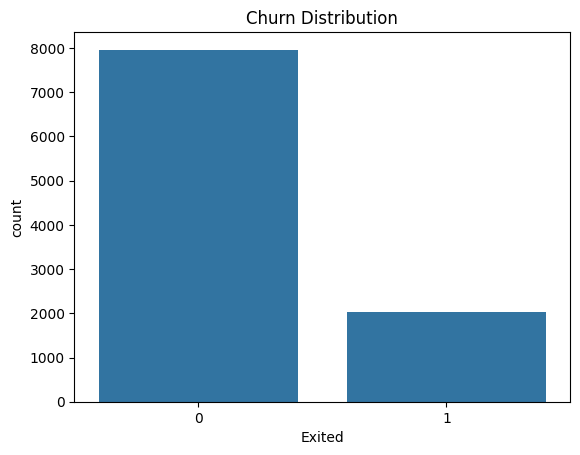

In [13]:
# Distribution of target variable
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='Exited', data=df)
plt.title("Churn Distribution")
plt.show()

✅ STEP 4: Preprocess the Data

In [14]:
from sklearn.preprocessing import LabelEncoder

# Label Encode categorical columns
le = LabelEncoder()
for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col])


In [15]:
# Drop rows with missing values
df = df.dropna()


In [17]:
# Define features and target
X = df.drop('Exited', axis=1)
y = df['Exited']

In [18]:
# Scale the features
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


In [19]:
# Train-test split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)


✅ STEP 5: Train Models

🔹 Logistic Regression

In [20]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

log_model = LogisticRegression()
log_model.fit(X_train, y_train)
log_preds = log_model.predict(X_test)

print("Logistic Regression Accuracy:", accuracy_score(y_test, log_preds))


Logistic Regression Accuracy: 0.8155


🔹 Random Forest

In [21]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier()
rf_model.fit(X_train, y_train)
rf_preds = rf_model.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, rf_preds))


Random Forest Accuracy: 0.8665


🔹 Gradient Boosting

In [22]:
from sklearn.ensemble import GradientBoostingClassifier

gb_model = GradientBoostingClassifier()
gb_model.fit(X_train, y_train)
gb_preds = gb_model.predict(X_test)

print("Gradient Boosting Accuracy:", accuracy_score(y_test, gb_preds))


Gradient Boosting Accuracy: 0.868


✅ STEP 6: Evaluate the Best Model (e.g., Gradient Boosting)

Classification Report:
               precision    recall  f1-score   support

           0       0.88      0.97      0.92      1607
           1       0.78      0.46      0.58       393

    accuracy                           0.87      2000
   macro avg       0.83      0.71      0.75      2000
weighted avg       0.86      0.87      0.85      2000



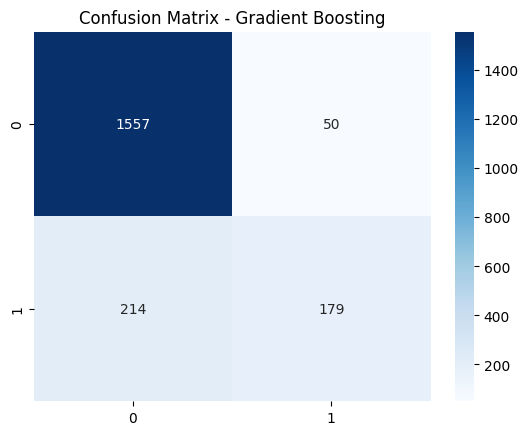

In [23]:
from sklearn.metrics import classification_report, confusion_matrix

print("Classification Report:\n", classification_report(y_test, gb_preds))

# Confusion matrix
sns.heatmap(confusion_matrix(y_test, gb_preds), annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - Gradient Boosting")
plt.show()


✅ STEP 7:  Handle Class Imbalance with SMOTE

In [24]:

!pip install imbalanced-learn


In [25]:
from imblearn.over_sampling import SMOTE

sm = SMOTE(random_state=42)
X_resampled, y_resampled = sm.fit_resample(X_scaled, y)

# Split the resampled data
X_train_res, X_test_res, y_train_res, y_test_res = train_test_split(
    X_resampled, y_resampled, test_size=0.2, random_state=42
)


In [26]:
gb_model_smote = GradientBoostingClassifier()
gb_model_smote.fit(X_train_res, y_train_res)
smote_preds = gb_model_smote.predict(X_test_res)

print("SMOTE-Enhanced Model Accuracy:", accuracy_score(y_test_res, smote_preds))
print(classification_report(y_test_res, smote_preds))


SMOTE-Enhanced Model Accuracy: 0.8706842435655995
              precision    recall  f1-score   support

           0       0.87      0.87      0.87      1633
           1       0.87      0.87      0.87      1553

    accuracy                           0.87      3186
   macro avg       0.87      0.87      0.87      3186
weighted avg       0.87      0.87      0.87      3186



✅ STEP 8: Feature Importance (for Tree-Based Models)

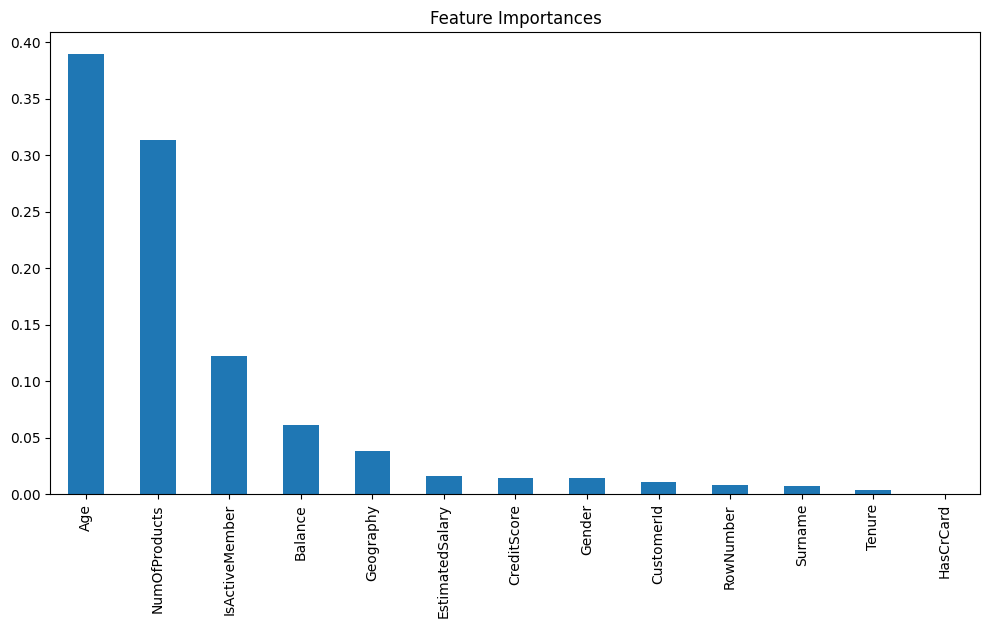

In [27]:
feature_importances = pd.Series(gb_model.feature_importances_, index=X.columns)
feature_importances.sort_values(ascending=False).plot(kind='bar', figsize=(12,6), title="Feature Importances")
plt.show()


✅ STEP 9: Save the Model (for Deployment)

In [28]:
predictions_df = pd.DataFrame({
    'Actual': y_test,
    'Predicted': gb_preds
})

predictions_df.to_csv("churn_predictions.csv", index=False)


✅ STEP 10: Export Predictions

In [29]:
predictions_df = pd.DataFrame({
    'Actual': y_test,
    'Predicted': gb_preds
})

predictions_df.to_csv("churn_predictions.csv", index=False)
